In [1]:
import re
with open('clinical.tsv') as f:
    header, *lines = f.readlines()
    data = {}
    for line in lines:
        cols = line.strip().split('\t')
        if cols[15] == 'Alive' and re.search(r'\d+', cols[47]): #cols[47] days_to_last_follow_up
            data.setdefault(cols[1], f'{int(cols[47]) // 30}\t0') 
        elif cols[15] == 'Dead' and re.search(r'\d+', cols[9]): #cols[9] days_to_death
            data.setdefault(cols[1], f'{int(cols[9]) // 30}\t1')
        else:
            print(line) #欠損値があれば出力する
    
with open('clinical_edited.tsv', 'w') as out:
    print('T', 'E', sep='\t', file=out)
    for value in data.values():
        print(value, file=out)  

68107725-a883-4b33-a366-d9b4adb18028	TCGA-63-5131	TCGA-LUSC	'--	'--	'--	'--	'--	'--	'--	not reported	male	'--	'--	not reported	Dead	'--	'--	'--	'--	'--	'--	'--	'--	M0	N1	Stage IIB	T2	6th	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	not reported	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	C34.9	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	not reported	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	8070/3	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	Squamous cell carcinoma, NOS	'--	no	No	not reported	'--	'--	'--	Lung, NOS	'--	'--	No	Lung, NOS	'--	'--	'--	'--	not reported	'--	'--	stage iib	'--	'--	'--	'--	'--	'--	2008	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	no	'--	Radiation Therapy, NOS

68107725-a883-4b33-a366-d9b4adb18028	TCGA-63-5131	TCGA-LUSC	'--	'--	'--	'--	'--	'--	'--	not reported	male	'--	'--	not reported	Dead	'--	'--	'--	'--	'--	'--	'--	'--	M0	N1	Stage IIB	T2	6th	'--	'--	'--	'--	'--	'--	'

In [2]:
import pandas as pd
df = pd.read_table('clinical_edited.tsv')

In [3]:
df

,T,E
0,112,0
1,27,1
2,90,0
3,19,0
4,120,1
...,...,...
486,22,1
487,18,0
488,34,0
489,5,1


In [4]:
T = df['T']
E = df['E']

<AxesSubplot:xlabel='timeline'>

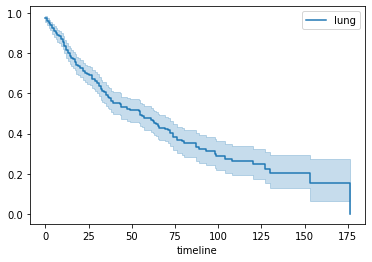

In [5]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E, label='lung')
kmf.survival_function_
kmf.plot_survival_function()

In [6]:
with open('clinical.tsv') as f:
    header, *lines = f.readlines()
    data = {}
    for line in lines:
        cols = line.strip().split('\t')
        if cols[15] == 'Alive' and re.search(r'\d+', cols[47]): #cols[47] days_to_last_follow_up
            if match := re.match('Stage (\w+)', cols[26]):
                stage = match.group(1)
                if stage == 'I' or stage == 'IA' or stage == 'IB' or stage == 'II' or stage == 'IIA' or stage == 'IIB':
                    data.setdefault(cols[1], f'{int(cols[47]) // 30}\t0\tstageI-II') 
                else:
                    data.setdefault(cols[1], f'{int(cols[47]) // 30}\t0\tstageIII-IV') 
        elif cols[15] == 'Dead' and re.search(r'\d+', cols[9]): #cols[9] days_to_death
             if match := re.match('Stage (\w+)', cols[26]):
                stage = match.group(1)
                if stage == 'I' or stage == 'IA' or stage == 'IB' or stage == 'II' or stage == 'IIA' or stage == 'IIB':
                    data.setdefault(cols[1], f'{int(cols[9]) // 30}\t1\tstageI-II') 
                else:
                    data.setdefault(cols[1], f'{int(cols[9]) // 30}\t1\tstageIII-IV') 
        else:
            print(line) #欠損値を出力
    
with open('clinical_group.tsv', 'w') as out:
    print('T', 'E', 'group', sep='\t', file=out)
    for value in data.values():
        print(value, file=out)  

68107725-a883-4b33-a366-d9b4adb18028	TCGA-63-5131	TCGA-LUSC	'--	'--	'--	'--	'--	'--	'--	not reported	male	'--	'--	not reported	Dead	'--	'--	'--	'--	'--	'--	'--	'--	M0	N1	Stage IIB	T2	6th	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	not reported	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	C34.9	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	not reported	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	8070/3	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	Squamous cell carcinoma, NOS	'--	no	No	not reported	'--	'--	'--	Lung, NOS	'--	'--	No	Lung, NOS	'--	'--	'--	'--	not reported	'--	'--	stage iib	'--	'--	'--	'--	'--	'--	2008	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	no	'--	Radiation Therapy, NOS

68107725-a883-4b33-a366-d9b4adb18028	TCGA-63-5131	TCGA-LUSC	'--	'--	'--	'--	'--	'--	'--	not reported	male	'--	'--	not reported	Dead	'--	'--	'--	'--	'--	'--	'--	'--	M0	N1	Stage IIB	T2	6th	'--	'--	'--	'--	'--	'--	'

In [7]:
df = pd.read_table('clinical_group.tsv')

In [8]:
df

,T,E,group
0,112,0,stageI-II
1,27,1,stageI-II
2,90,0,stageI-II
3,19,0,stageI-II
4,120,1,stageI-II
...,...,...,...
482,22,1,stageI-II
483,18,0,stageI-II
484,34,0,stageI-II
485,5,1,stageI-II


In [9]:
T12 = df.loc[df['group'] == 'stageI-II', 'T']
E12 = df.loc[df['group'] == 'stageI-II', 'E']

T34 = df.loc[df['group'] == 'stageIII-IV', 'T']
E34 = df.loc[df['group'] == 'stageIII-IV', 'E']

In [10]:
E12

0      0
1      1
2      0
3      0
4      1
      ..
482    1
483    0
484    0
485    1
486    0
Name: E, Length: 397, dtype: int64

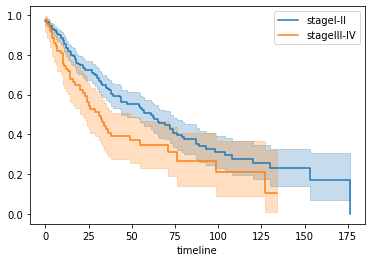

In [11]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()

kmf.fit(T12, event_observed=E12, label='stageI-II')
ax = kmf.plot()

kmf.fit(T34, event_observed=E34, label='stageIII-IV')
ax = kmf.plot()

In [12]:
from lifelines.datasets import load_waltons
df = load_waltons()

In [13]:
df

,T,E,group
0,6.0,1,miR-137
1,13.0,1,miR-137
2,13.0,1,miR-137
3,13.0,1,miR-137
4,19.0,1,miR-137
...,...,...,...
158,60.0,1,control
159,60.0,1,control
160,60.0,1,control
161,60.0,1,control


In [14]:
T = df['T']
E = df['E']

In [15]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 163 total observations, 7 right-censored observations>

<AxesSubplot:xlabel='timeline'>

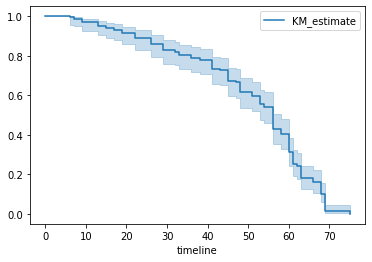

In [16]:
kmf.survival_function_
kmf.cumulative_density_
kmf.plot_survival_function()

<AxesSubplot:xlabel='timeline'>

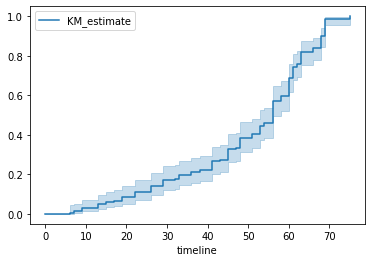

In [17]:
kmf.plot_cumulative_density()

In [18]:
T

0       6.0
1      13.0
2      13.0
3      13.0
4      19.0
       ... 
158    60.0
159    60.0
160    60.0
161    60.0
162    66.0
Name: T, Length: 163, dtype: float64

In [19]:
E

0      1
1      1
2      1
3      1
4      1
      ..
158    1
159    1
160    1
161    1
162    1
Name: E, Length: 163, dtype: int64

In [20]:
df

,T,E,group
0,6.0,1,miR-137
1,13.0,1,miR-137
2,13.0,1,miR-137
3,13.0,1,miR-137
4,19.0,1,miR-137
...,...,...,...
158,60.0,1,control
159,60.0,1,control
160,60.0,1,control
161,60.0,1,control


In [21]:
groups = df['group']

In [22]:
groups

0      miR-137
1      miR-137
2      miR-137
3      miR-137
4      miR-137
        ...   
158    control
159    control
160    control
161    control
162    control
Name: group, Length: 163, dtype: object

In [23]:
ix = (groups == 'miR-137')

In [24]:
ix

0       True
1       True
2       True
3       True
4       True
       ...  
158    False
159    False
160    False
161    False
162    False
Name: group, Length: 163, dtype: bool

In [25]:
groups == 'miR-137'

0       True
1       True
2       True
3       True
4       True
       ...  
158    False
159    False
160    False
161    False
162    False
Name: group, Length: 163, dtype: bool

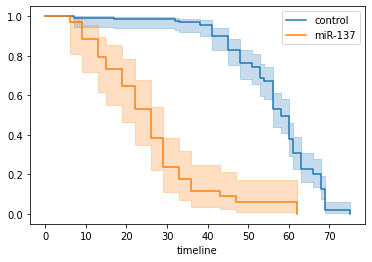

In [26]:
kmf.fit(df.loc[df['group'] == 'control', 'T'], df.loc[df['group'] == 'control', 'E'], label='control')
ax = kmf.plot()

kmf.fit(df.loc[df['group'] == 'miR-137', 'T'], df.loc[df['group'] == 'miR-137', 'E'], label='miR-137')
ax = kmf.plot(ax=ax)

In [27]:
df.loc[df['E'] == 0]

,T,E,group
39,61.0,0,control
41,61.0,0,control
54,69.0,0,control
71,68.0,0,control
89,7.0,0,control
144,45.0,0,control
152,60.0,0,control


In [28]:
import pandas as pd

In [29]:
df = pd.read_table('clinical.tsv')

In [30]:
df

,case_id,case_submitter_id,project_id,age_at_index,age_is_obfuscated,cause_of_death,cause_of_death_source,country_of_residence_at_enrollment,days_to_birth,days_to_death,...,treatment_arm,treatment_dose,treatment_dose_units,treatment_effect,treatment_effect_indicator,treatment_frequency,treatment_intent_type,treatment_or_therapy,treatment_outcome,treatment_type
0,14a4a93a-e24d-46f2-bee3-18bd792ef95a,TCGA-39-5019,TCGA-LUSC,70,'--,'--,'--,'--,-25756,'--,...,'--,'--,'--,'--,'--,'--,'--,no,'--,"Pharmaceutical Therapy, NOS"
1,14a4a93a-e24d-46f2-bee3-18bd792ef95a,TCGA-39-5019,TCGA-LUSC,70,'--,'--,'--,'--,-25756,'--,...,'--,'--,'--,'--,'--,'--,'--,no,'--,"Radiation Therapy, NOS"
2,037c57d1-b4a5-45dc-bda4-0550461d321b,TCGA-22-1016,TCGA-LUSC,65,'--,'--,'--,'--,-24078,822,...,'--,'--,'--,'--,'--,'--,'--,no,'--,"Pharmaceutical Therapy, NOS"
3,037c57d1-b4a5-45dc-bda4-0550461d321b,TCGA-22-1016,TCGA-LUSC,65,'--,'--,'--,'--,-24078,822,...,'--,'--,'--,'--,'--,'--,'--,no,'--,"Radiation Therapy, NOS"
4,a2d7c06b-efa9-4b7e-9ea6-b47c9ad6ef38,TCGA-63-A5MR,TCGA-LUSC,70,'--,'--,'--,'--,-25879,'--,...,'--,'--,'--,'--,'--,'--,'--,no,'--,"Pharmaceutical Therapy, NOS"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
989,4eaf5d63-9b33-4c7f-871e-45daa735f972,TCGA-34-A5IX,TCGA-LUSC,80,'--,'--,'--,'--,-29391,'--,...,'--,'--,'--,'--,'--,'--,'--,no,'--,"Pharmaceutical Therapy, NOS"
990,72c49014-f949-4d02-ae71-26a243e0b102,TCGA-52-7809,TCGA-LUSC,74,'--,'--,'--,'--,-27233,166,...,'--,'--,'--,'--,'--,'--,'--,not reported,'--,"Pharmaceutical Therapy, NOS"
991,72c49014-f949-4d02-ae71-26a243e0b102,TCGA-52-7809,TCGA-LUSC,74,'--,'--,'--,'--,-27233,166,...,'--,'--,'--,'--,'--,'--,'--,not reported,'--,"Radiation Therapy, NOS"
992,18f18672-2a23-4e26-987b-38c454ff46c7,TCGA-34-5927,TCGA-LUSC,70,'--,'--,'--,'--,-25857,'--,...,'--,'--,'--,'--,'--,'--,'--,no,'--,"Radiation Therapy, NOS"


In [31]:
Ta = df.loc[df['vital_status'] == 'Alive' , 'days_to_last_follow_up']

In [32]:
Ta

0      3387
1      3387
4      2716
5      2716
6       581
       ... 
987     557
988    1031
989    1031
992    1361
993    1361
Name: days_to_last_follow_up, Length: 558, dtype: object

In [33]:
Td = df.loc[df['vital_status'] == 'Dead', 'days_to_death']

In [34]:
Td

2       822
3       822
8      3600
9      3600
20      827
       ... 
983     740
984     687
985     687
990     166
991     166
Name: days_to_death, Length: 436, dtype: object

In [35]:
T = pd.concat([Ta, Td])

In [36]:
T

0      3387
1      3387
4      2716
5      2716
6       581
       ... 
983     740
984     687
985     687
990     166
991     166
Length: 994, dtype: object

In [37]:
df.loc[df['vital_status'] == 'Alive', 'vital_status'] = 0
df.loc[df['vital_status'] == 'Dead', 'vital_status'] = 1

In [38]:
Ea = df.loc[df['vital_status'] == 0, 'vital_status']
Ed = df.loc[df['vital_status'] == 1, 'vital_status']

In [39]:
Ea

0      0
1      0
4      0
5      0
6      0
      ..
987    0
988    0
989    0
992    0
993    0
Name: vital_status, Length: 558, dtype: object

In [40]:
Ed

2      1
3      1
8      1
9      1
20     1
      ..
983    1
984    1
985    1
990    1
991    1
Name: vital_status, Length: 436, dtype: object

In [41]:
E = pd.concat([Ea, Ed])

In [42]:
E

0      0
1      0
4      0
5      0
6      0
      ..
983    1
984    1
985    1
990    1
991    1
Name: vital_status, Length: 994, dtype: object

In [43]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed = E)

/usr/local/lib/python3.8/site-packages/lifelines/utils/__init__.py:1176: UserWarning: Attempting to convert an unexpected datatype 'object' to float. Suggestion: 1) use `lifelines.utils.datetimes_to_durations` to do conversions or 2) manually convert to floats/booleans.
  warnings.warn(warning_text, UserWarning)


TypeError: Wrong dtype 'object'.

In [ ]:
T.to_csv('T.txt', sep='\t')

In [ ]:
E.to_csv('E.txt', sep='\t')